In [5]:
import socket
node = socket.gethostname()
assert 'login' not in node, f"❌ STOP — on login node {node}!"
print(f"✅ Safe on: {node}")

✅ Safe on: c0310.ll.unc.edu


In [1]:
print("Hello")

Hello


In [ ]:
import datetime
import io
import sys
import os
from pathlib import Path
import unicodedata
from datetime import datetime, timezone

import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import pybaseball
import requests
import shap
import lightgbm as lgb
import scipy.stats as stats
from tqdm import tqdm
from bs4 import BeautifulSoup
from pybaseball import statcast
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss, mean_squared_error, mean_absolute_error, r2_score
from sklearn.calibration import calibration_curve

# Resolve the repository from the current working directory on any OS.
PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'src' / 'mlb_props').is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError('Run this notebook from somewhere inside the MLB-Props repository.')
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from mlb_props.config import (
    MODEL_DIR,
    OPTUNA_DIR,
    OUTPUT_DIR,
    PITCHER_STARTS_PATH,
    PREDICTION_DIR,
    ROSTER_SCRAPER_DIR,
    SHAP_DIR,
    ensure_output_directories,
)
from mlb_props.features import TARGET, validate_pregame_features

ensure_output_directories()
sys.path.insert(0, str(ROSTER_SCRAPER_DIR))
from RosterScraper import RosterScraper

In [12]:
if not PITCHER_STARTS_PATH.exists():
    raise FileNotFoundError(
        f"Pitcher-start data not found at {PITCHER_STARTS_PATH}. "
        "Set MLB_PROPS_PITCHER_STARTS or MLB_PROPS_DATA_DIR."
    )
Starts = pl.read_parquet(PITCHER_STARTS_PATH)
df = Starts.to_pandas()

# Data Collection

In [13]:
# ── Define windows once ───────────────────────────────────────────────────────
OUTCOME_WINDOWS  = [5, 10, 20]
PHYSICS_WINDOWS  = [1, 3, 5, 10]
ARSENAL_WINDOWS  = [1]
INTERACT_WINDOWS = [1, 3, 5]

df = df.sort_values(['player_name', 'game_date']).reset_index(drop=True)

# ── Derived columns ───────────────────────────────────────────────────────────
df['k_rate'] = df['K'] / df['PA'].clip(lower=1)

# ── Winsorize xBA/xwOBA before rolling ───────────────────────────────────────
for col in ['xBA', 'xwOBA']:
    if col in df.columns:
        lo = df[col].quantile(0.05)
        hi = df[col].quantile(0.95)
        df[f'{col}_clipped'] = df[col].clip(lo, hi)

# ── Compute interaction/tunneling cols from raw physics (for rolling only) ────
df['ff_power_angle']   = df['ff_velo'] * df['ff_vaa'].abs()
df['ch_effectiveness'] = df['throws_ch'] * df['ch_vaa'].abs()
df['ff_ch_velo_diff']  = df['ff_velo'] - df['ch_velo']
df['ff_sl_velo_diff']  = df['ff_velo'] - df['sl_velo']
df['ff_si_velo_diff']  = df['ff_velo'] - df['si_velo']
df['ff_ch_ivb_diff']   = df['ff_ivb'] - df['ch_ivb']
df['ff_sl_ivb_diff']   = df['ff_ivb'] - df['sl_ivb']
df['ff_ch_vaa_diff']   = df['ff_vaa'] - df['ch_vaa']
df['ch_platoon_split'] = df['ch_usage_vL'] - df['ch_usage_vR']
df['sl_platoon_split'] = df['sl_usage_vL'] - df['sl_usage_vR']

# ── Rolling features — outcomes, physics, arsenal, interactions ───────────────
roll_features = {}

for window in OUTCOME_WINDOWS:
    # BEFORE
    for stat in ['k_rate', 'Whiffs', 'CSW', 'CS', 'GB', 'BB', 'Strikes', 'Balls', 'BIP', "PA"]:
        roll_features[f'{stat}_P{window}'] = (
            df.groupby('player_name')[stat]
            .transform(lambda x, w=window: x.shift(1).rolling(w, min_periods=min(3, w)).mean())
        )
    for src in ['xBA_clipped', 'xwOBA_clipped']:
        if src in df.columns:
            roll_features[f'{src}_P{window}'] = (
                df.groupby('player_name')[src]
                .transform(lambda x, w=window: x.shift(1).rolling(w, min_periods=min(3, w)).mean())
            )

for window in PHYSICS_WINDOWS:
    for stat in [
        'ff_velo', 'ff_spinrate', 'ff_ivb', 'ff_hb', 'ff_vaa',
        'sl_velo', 'sl_spinrate', 'sl_ivb', 'sl_hb', 'sl_vaa',
        'ch_velo', 'ch_spinrate', 'ch_ivb', 'ch_hb', 'ch_vaa',
        'si_velo', 'si_spinrate', 'si_ivb', 'si_hb', 'si_vaa',
        'cu_velo', 'cu_spinrate', 'cu_ivb', 'cu_hb', 'cu_vaa',
        'fc_velo', 'fc_spinrate', 'fc_ivb', 'fc_hb', 'fc_vaa',
        'st_velo', 'st_spinrate', 'st_ivb', 'st_hb', 'st_vaa',
    ]:
        roll_features[f'{stat}_P{window}'] = (
            df.groupby('player_name')[stat]
            .transform(lambda x, w=window: x.shift(1).rolling(w, min_periods=min(3, w)).mean()))

for window in ARSENAL_WINDOWS:
    for stat in ['ff_usage_vR', 'ff_usage_vL', 'sl_usage_vR', 'sl_usage_vL',
                 'ch_usage_vR', 'ch_usage_vL']:
        roll_features[f'{stat}_P{window}'] = (
            df.groupby('player_name')[stat]
            .transform(lambda x, w=window: x.shift(1).rolling(w, min_periods=min(3, w)).mean()))

for window in INTERACT_WINDOWS:
    for stat in ['ff_power_angle', 'ch_effectiveness', 'ff_ch_velo_diff',
                 'ff_sl_velo_diff', 'ff_si_velo_diff', 'ff_ch_ivb_diff',
                 'ff_sl_ivb_diff', 'ff_ch_vaa_diff', 'ch_platoon_split', 'sl_platoon_split']:
        roll_features[f'{stat}_P{window}'] = (
            df.groupby('player_name')[stat]
            .transform(lambda x, w=window: x.shift(1).rolling(w, min_periods=min(3, w)).mean()))

# Drop any pre-existing rolling columns before concat
existing_roll_cols = [c for c in roll_features.keys() if c in df.columns]
df = df.drop(columns=existing_roll_cols)
df = pd.concat([df, pd.DataFrame(roll_features, index=df.index)], axis=1)

# ── Shrunk rolling features ───────────────────────────────────────────────────
pop_csw = df['CSW'].mean()
pop_bb  = df['BB'].mean()
df['CSW_P20_shrunk'] = 0.58 * df['CSW_P20'].squeeze() + 0.42 * pop_csw
df['BB_P20_shrunk']  = 0.51 * df['BB_P20'].squeeze()  + 0.49 * pop_bb

# ── Feature lists — ALL now rolled, nothing same-game ─────────────────────────
physics_features = [f'{p}_P{w}' for p in [
    'ff_velo', 'ff_spinrate', 'ff_ivb', 'ff_hb', 'ff_vaa',
    'sl_velo', 'sl_spinrate', 'sl_ivb', 'sl_hb', 'sl_vaa',
    'ch_velo', 'ch_spinrate', 'ch_ivb', 'ch_hb', 'ch_vaa',
    'si_velo', 'si_spinrate', 'si_ivb', 'si_hb', 'si_vaa',
    'cu_velo', 'cu_spinrate', 'cu_ivb', 'cu_hb', 'cu_vaa',
    'fc_velo', 'fc_spinrate', 'fc_ivb', 'fc_hb', 'fc_vaa',
    'st_velo', 'st_spinrate', 'st_ivb', 'st_hb', 'st_vaa',
] for w in PHYSICS_WINDOWS]

rolling_features = [c for c in df.columns if any(
    c.startswith(s) for s in ['k_rate_P', 'Whiffs_P', 'CSW_P', 'CS_P',
                               'GB_P', 'BB_P', 'Strikes_P', 'Balls_P', 'BIP_P',
                               'xBA_clipped_P', 'xwOBA_clipped_P']
) and not c.endswith('_shrunk')]

arsenal_features = [f'{p}_P{w}' for p in [
    'ff_usage_vR', 'ff_usage_vL', 'sl_usage_vR', 'sl_usage_vL',
    'ch_usage_vR', 'ch_usage_vL',
] for w in ARSENAL_WINDOWS]

interaction_feats = [f'{p}_P{w}' for p in [
    'ff_power_angle', 'ch_effectiveness',
    'ff_ch_velo_diff', 'ff_sl_velo_diff', 'ff_si_velo_diff',
    'ff_ch_ivb_diff',  'ff_sl_ivb_diff',  'ff_ch_vaa_diff',
    'ch_platoon_split', 'sl_platoon_split',
] for w in INTERACT_WINDOWS] + ['CSW_P20_shrunk', 'BB_P20_shrunk']

# Same-game PA is used only to define/filter the target row, never as input.
context_features = []

ALL_FEATURES = (
    physics_features + rolling_features +
    arsenal_features + context_features + interaction_feats
)

FEATURES_TO_DROP = {
    'CS_P10', 'CS_P5', 'CS_P20',
    'Strikes_P20',
    'Balls_P10', 'Balls_P20',
    'BB_P5', 'BB_P10',
    'CSW_P5', 'CSW_P10',
    'GB_P20',
    'BIP_P5', 'BIP_P10', 'BIP_P20',
    'Whiffs_P5',
    'ch_usage_vL_P10', 'ch_usage_vL_P3', 'ch_usage_vL_P5',
    'ch_usage_vR_P1', 'ch_usage_vR_P3', 'ch_usage_vR_P5', 'ch_usage_vR_P10',
    'ff_usage_vR_P3', 'ff_usage_vR_P5', 'ff_usage_vR_P10',
    'ff_usage_vL_P5', 'ff_usage_vL_P10',
    'sl_usage_vR_P1', 'sl_usage_vR_P3', 'sl_usage_vR_P5', 'sl_usage_vR_P10',
    'sl_usage_vL_P1', 'sl_usage_vL_P3', 'sl_usage_vL_P5', 'sl_usage_vL_P10',
}

ALL_FEATURES = list(validate_pregame_features(
    f for f in ALL_FEATURES if f not in FEATURES_TO_DROP
))

# ── Sanity checks ─────────────────────────────────────────────────────────────
print(f"Feature count: {len(ALL_FEATURES)}")

# Verify new windows exist
p1_cols = [c for c in df.columns if c.endswith('_P1')]
p3_cols = [c for c in df.columns if c.endswith('_P3')]
print(f"P1 features in df: {len(p1_cols)}")
print(f"P3 features in df: {len(p3_cols)}")

# ── Impute nulls ──────────────────────────────────────────────────────────────
for col in physics_features + interaction_feats:
    if col in df.columns:
        df[col] = df[col].fillna(0)

for col in rolling_features:
    df[col] = df[col].fillna(df[col].mean())

df = df[df['PA'] >= 6]

Feature count: 194
P1 features in df: 51
P3 features in df: 45


In [14]:
# sample = df.iloc[::33].to_csv("/nas/longleaf/home/kapcam/MLB/Strikeout-model/sample_3pct.csv", index=False)
# print(f"Saved {len(df.iloc[::33]):,} rows ({len(df.iloc[::33])/len(df)*100:.1f}% of {len(df):,})")

# Train Test Val Split

In [15]:
# ── Chronological 70/15/15 split ─────────────────────────────────────────────
model_df = df[ALL_FEATURES + [TARGET, 'game_date', 'player_name']].dropna()
print(f"Rows: {len(model_df)}")

dates = model_df['game_date'].sort_values()
n = len(model_df)
train_cutoff = dates.iloc[int(n * 0.70)]
val_cutoff   = dates.iloc[int(n * 0.85)]

train = model_df[model_df['game_date'] < train_cutoff]
val   = model_df[(model_df['game_date'] >= train_cutoff) & (model_df['game_date'] < val_cutoff)]
test  = model_df[model_df['game_date'] >= val_cutoff]

print(f"Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")
print(f"Train ends:  {train['game_date'].max()}")
print(f"Val ends:    {val['game_date'].max()}")
print(f"Test starts: {test['game_date'].min()}")

X_train = train[ALL_FEATURES];  y_train = train[TARGET]
X_val   = val[ALL_FEATURES];    y_val   = val[TARGET]
X_test  = test[ALL_FEATURES];   y_test  = test[TARGET]

Rows: 13662
Train: 9,542 | Val: 2,063 | Test: 2,057
Train ends:  2025-04-20 00:00:00
Val ends:    2025-07-08 00:00:00
Test starts: 2025-07-09 00:00:00


# Model Definition

In [16]:
monotone_map = {
    **{f'ff_velo_P{w}':          +1 for w in PHYSICS_WINDOWS},
    **{f'ff_vaa_P{w}':           +1 for w in PHYSICS_WINDOWS},
    **{f'ff_ivb_P{w}':           +1 for w in PHYSICS_WINDOWS},
    **{f'ff_spinrate_P{w}':      +1 for w in PHYSICS_WINDOWS},
    **{f'sl_vaa_P{w}':           -1 for w in PHYSICS_WINDOWS},
    **{f'k_rate_P{w}':           +1 for w in OUTCOME_WINDOWS},
    **{f'Whiffs_P{w}':           +1 for w in OUTCOME_WINDOWS},
    **{f'CSW_P{w}':              +1 for w in OUTCOME_WINDOWS},
    **{f'BB_P{w}':               -1 for w in OUTCOME_WINDOWS},
    **{f'BIP_P{w}':              -1 for w in OUTCOME_WINDOWS},
    **{f'ff_power_angle_P{w}':   +1 for w in INTERACT_WINDOWS},
    **{f'ff_ch_velo_diff_P{w}':  +1 for w in INTERACT_WINDOWS},
    'CSW_P20_shrunk':             +1,
    'BB_P20_shrunk':              -1,
}

monotone_constraints = [monotone_map.get(f, 0) for f in ALL_FEATURES]
print(f"Constrained: {sum(c != 0 for c in monotone_constraints)} / {len(monotone_constraints)}")

Constrained: 35 / 194


In [ ]:
# ── LightGBM (230 features) ───────────────────────────────────────────────────
model_lgb = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=12000,
    learning_rate=0.02,
    num_leaves=63,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.6,
    reg_alpha=0.1,
    reg_lambda=2.0,
    monotone_constraints=monotone_constraints,
    monotone_constraints_method='advanced',
    random_state=42,
    verbose=-1,
)

model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(150), lgb.log_evaluation(500)]
)

for name, X, y in [('Val', X_val, y_val), ('Test', X_test, y_test)]:
    preds = model_lgb.predict(X).clip(0, 1)
    print(f"\nLightGBM [{name}]")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y, preds)):.4f}")
    print(f"  MAE:  {mean_absolute_error(y, preds):.4f}")
    print(f"  R²:   {r2_score(y, preds):.4f}")

Constrained: 35 / 194
Training until validation scores don't improve for 150 rounds
[500]	valid_0's l2: 0.00578719
[1000]	valid_0's l2: 0.00415789
[1500]	valid_0's l2: 0.00330718
[2000]	valid_0's l2: 0.0028418
[2500]	valid_0's l2: 0.002565
[3000]	valid_0's l2: 0.00239715
[3500]	valid_0's l2: 0.00228099
[4000]	valid_0's l2: 0.0022012
[4500]	valid_0's l2: 0.00214807
[5000]	valid_0's l2: 0.00211135
[5500]	valid_0's l2: 0.00208315
[6000]	valid_0's l2: 0.0020644
Early stopping, best iteration is:
[6290]	valid_0's l2: 0.00205849

LightGBM [Val]
  RMSE: 0.0454
  MAE:  0.0289
  R²:   0.8113

LightGBM [Test]
  RMSE: 0.0367
  MAE:  0.0179
  R²:   0.8840


# SHAP

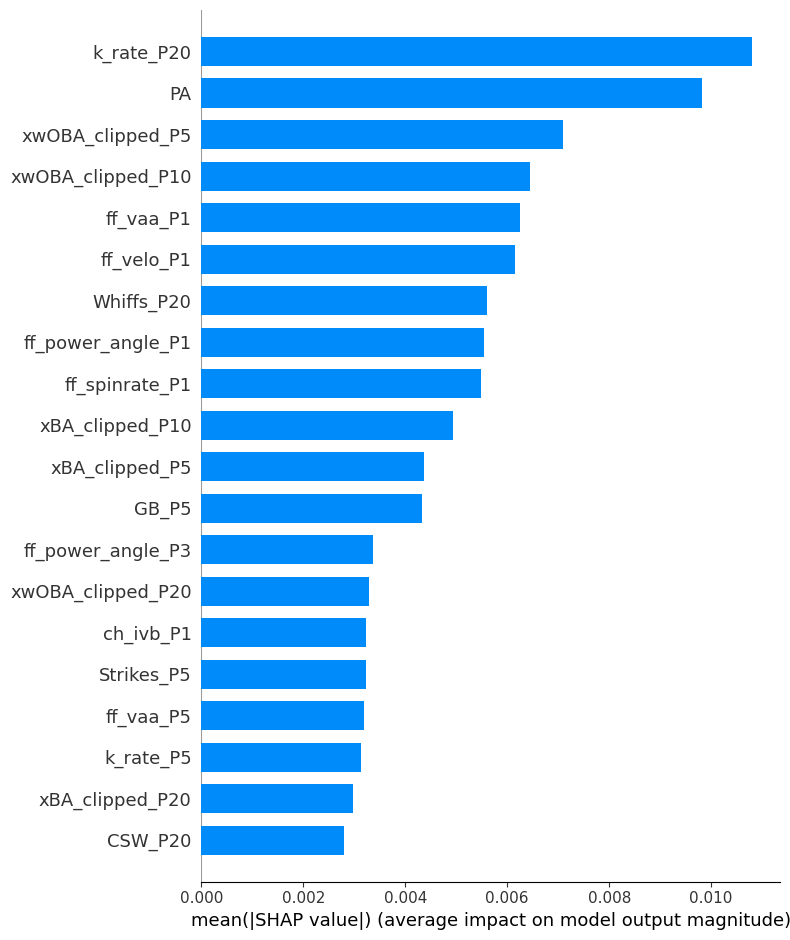


=== SHAP Rankings (v7 — 138 features) ===

                 feature  mean_abs_shap  mean_shap
1             k_rate_P20        0.01081   -0.00094
2                     PA        0.00981    0.00003
3       xwOBA_clipped_P5        0.00709   -0.00082
4      xwOBA_clipped_P10        0.00645   -0.00061
5              ff_vaa_P1        0.00624    0.00038
6             ff_velo_P1        0.00615   -0.00021
7             Whiffs_P20        0.00561   -0.00061
8      ff_power_angle_P1        0.00555   -0.00048
9         ff_spinrate_P1        0.00549    0.00006
10       xBA_clipped_P10        0.00494    0.00041
11        xBA_clipped_P5        0.00437    0.00055
12                 GB_P5        0.00434   -0.00002
13     ff_power_angle_P3        0.00336    0.00034
14     xwOBA_clipped_P20        0.00329   -0.00031
15             ch_ivb_P1        0.00324   -0.00011
16            Strikes_P5        0.00323    0.00033
17             ff_vaa_P5        0.00319   -0.00023
18             k_rate_P5        0.0031

In [6]:
# ── SHAP ──────────────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(model_lgb)
shap_values = explainer.shap_values(X_val)
shap.summary_plot(shap_values, X_val, feature_names=ALL_FEATURES, plot_type='bar')

shap_table = (
    pd.DataFrame({
        'feature':       ALL_FEATURES,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0),
        'mean_shap':     shap_values.mean(axis=0),})
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True))

shap_table.index += 1
print("\n=== SHAP Rankings (v7 — 138 features) ===\n")
print(shap_table.to_string(float_format=lambda x: f"{x:.5f}"))

# ── Save with datetime stamp ──────────────────────────────────────────────────
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
save_path = MODEL_DIR / f"lgb_{len(ALL_FEATURES)}feat_{ts}.txt"
model_lgb.booster_.save_model(str(save_path))
print(f"\nModel saved → {save_path}")

In [7]:
# ── Run after SHAP cell ───────────────────────────────────────────────────────
SHAP_THRESHOLD = 0.0015  # adjust after seeing the new table

noise_features = shap_table[shap_table['mean_abs_shap'] < SHAP_THRESHOLD]['feature'].tolist()

# Never drop physics or interaction features blindly — only rolling/arsenal candidates
protected = set(physics_features + interaction_feats)
safe_to_drop = [f for f in noise_features if f not in protected]

ALL_FEATURES_PRUNED = [f for f in ALL_FEATURES if f not in safe_to_drop]
print(f"Dropping {len(safe_to_drop)} features: {safe_to_drop}")
print(f"Pruned feature count: {len(ALL_FEATURES_PRUNED)}")

Dropping 0 features: []
Pruned feature count: 194


In [14]:
df["PA"].describe()

count    14129.000000
mean        22.319414
std          4.157362
min          6.000000
25%         20.000000
50%         23.000000
75%         25.000000
max         34.000000
Name: PA, dtype: float64

In [10]:
pd.concat([X_test, y_test], axis=1)

,ff_velo_P1,ff_velo_P3,ff_velo_P5,ff_velo_P10,ff_spinrate_P1,ff_spinrate_P3,ff_spinrate_P5,ff_spinrate_P10,ff_ivb_P1,ff_ivb_P3,...,ff_ch_vaa_diff_P5,ch_platoon_split_P1,ch_platoon_split_P3,ch_platoon_split_P5,sl_platoon_split_P1,sl_platoon_split_P3,sl_platoon_split_P5,CSW_P20_shrunk,BB_P20_shrunk,k_rate
99,0.000000,0.000000,92.537500,92.569530,0.000000,0.000000,2439.958333,2437.807692,0.000000,0.000000,...,2.351725,0.000000,0.016018,0.037036,-0.016393,-0.005464,-0.003279,23.766849,1.689334,0.214286
100,91.650000,0.000000,92.337500,92.489900,2378.500000,0.000000,2416.958333,2432.944729,17.580000,0.000000,...,2.955608,0.015873,0.012537,0.035863,0.000000,-0.005464,-0.003279,24.085849,1.663834,0.190476
101,92.100000,0.000000,92.329167,92.442037,2412.000000,0.000000,2423.125000,2427.081481,17.720000,0.000000,...,2.608196,0.015625,0.010499,0.015911,-0.043478,-0.019957,-0.011974,24.085849,1.740334,0.136364
102,91.900000,91.883333,92.087500,92.343889,2368.222222,2386.240741,2401.430556,2417.939506,17.746667,17.682222,...,3.145037,0.037037,0.022845,0.018055,0.000000,-0.014493,-0.011974,23.998849,1.714834,0.150000
103,91.909091,91.969697,91.889773,92.270455,2306.727273,2362.316498,2366.362374,2409.753648,16.734545,17.400404,...,3.047067,0.022222,0.024961,0.018151,0.000000,-0.014493,-0.011974,23.737849,1.689334,0.208333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14347,94.982857,94.789158,94.820770,94.923102,2248.628571,2232.520879,2228.109122,2231.930562,16.484571,17.056029,...,2.671582,0.033636,0.060101,0.072387,-0.166364,-0.162306,-0.117747,22.000079,1.332334,0.160000
14348,94.732353,94.982848,94.833123,94.898051,2292.970588,2266.485434,2242.485592,2236.364764,18.596471,17.518443,...,2.961234,0.029412,0.047683,0.061943,-0.135294,-0.149071,-0.138091,22.117992,1.332334,0.294118
14349,94.986957,94.900722,94.817356,94.923512,2236.347826,2259.315662,2245.376210,2230.702488,16.267826,17.116289,...,2.879041,0.290323,0.117790,0.100007,-0.235484,-0.179047,-0.171539,21.949515,1.366334,0.263158
14350,95.075000,94.931436,95.002100,94.932316,2229.107143,2252.808519,2252.982254,2229.978419,16.337143,17.067147,...,2.957737,0.142857,0.154197,0.115246,-0.352381,-0.241053,-0.207016,21.838349,1.364209,0.333333


# Residuals

In [ ]:
# Save SHAP table and predictions under the configured artifact directory.
shap_table.to_csv(SHAP_DIR / "shap_table_lgb.csv", index=False)

pred_df = test[['game_date', TARGET]].copy()
pred_df['pred'] = model_lgb.predict(X_test).clip(0, 1)
pred_df['resid'] = pred_df[TARGET] - pred_df['pred']
pred_df.to_csv(PREDICTION_DIR / "test_predictions_lgb.csv", index=False)

# Worst misses
pred_df.reindex(pred_df['resid'].abs().sort_values(ascending=False).index).head(25)

# Ablation table

In [ ]:
# Drop bottom 15 features and retrain
noise_features = shap_table[shap_table['mean_abs_shap'] < 0.0015]['feature'].tolist()
# Also exclude anything in interaction_feats or physics_features — never drop physics blindly
safe_to_drop = [f for f in noise_features if f not in physics_features + interaction_feats]
print(f"Candidates to drop: {safe_to_drop}")

ALL_FEATURES_PRUNED = [f for f in ALL_FEATURES if f not in safe_to_drop]
print(f"Pruned feature count: {len(ALL_FEATURES_PRUNED)}")

In [ ]:
def run_lgb(feature_list, label="", n_est=3000):
    mono = [monotone_map.get(f, 0) for f in feature_list]
    m = lgb.LGBMRegressor(
    objective='regression', n_estimators=3000, learning_rate=0.05,
    num_leaves=31,          # was 63 — halves tree complexity
    min_child_samples=50, subsample=0.8,
    colsample_bytree=0.6, reg_alpha=0.1, reg_lambda=2.0,
    monotone_constraints=mono, monotone_constraints_method='advanced',
    random_state=42, verbose=-1, n_jobs=4,  # cap at 4 instead of -1
    )
    m.fit(X_train[feature_list], y_train,
          eval_set=[(X_val[feature_list], y_val)],
          callbacks=[lgb.early_stopping(150), lgb.log_evaluation(-1)])
    preds = m.predict(X_test[feature_list]).clip(0, 1)
    return {
        'config': label,
        'n_features': len(feature_list),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE':  mean_absolute_error(y_test, preds),
        'R2':   r2_score(y_test, preds),
    }

ablation_configs = [
    (ALL_FEATURES,                                              "Full model"),
    ([f for f in ALL_FEATURES if f not in physics_features],   "No physics"),
    ([f for f in ALL_FEATURES if f not in rolling_features],   "No rolling"),
    ([f for f in ALL_FEATURES if f not in arsenal_features],   "No arsenal"),
    ([f for f in ALL_FEATURES if f not in interaction_feats],  "No interactions"),
    (physics_features,                                          "Physics only"),
    (rolling_features,                                          "Rolling only"),
]

results = []
for features, label in tqdm(ablation_configs, desc="Ablation runs"):
    results.append(run_lgb(features, label))

In [ ]:
abl = pd.DataFrame(results)
baseline_rmse = abl.loc[abl['config'] == 'Full model', 'RMSE'].values[0]
baseline_r2   = abl.loc[abl['config'] == 'Full model', 'R2'].values[0]
abl['ΔRMSE'] = (abl['RMSE'] - baseline_rmse).round(4)
abl['ΔR²']   = (abl['R2']   - baseline_r2).round(4)
print(abl.to_string(index=False))

# Leakage

In [ ]:
# Pick a pitcher with many starts
pitcher = df['player_name'].value_counts().index[0]
audit = df[df['player_name'] == "Dylan Cease"][
    ['game_date', 'player_name', 'k_rate', 'k_rate_P5']
].sort_values('game_date').head(15)
print(audit.to_string(index=True))

# What you want to see:
# Row 0-2: k_rate_P5 = NaN (not enough history yet)
# Row 3+:  k_rate_P5 reflects only PRIOR games, never the current row
# Red flag: k_rate_P5 on row N correlates suspiciously well with k_rate on row N

In [ ]:
# Quantitative leakage check — if shift(1) worked, correlation should be modest
# A suspiciously high value (>0.95) suggests the current game is leaking in
from scipy.stats import pearsonr

mask = df['k_rate_P5'].notna()
r, p = pearsonr(df.loc[mask, 'k_rate'], df.loc[mask, 'k_rate_P5'])
print(f"Pearson r(k_rate, k_rate_P5): {r:.4f}  (p={p:.2e})")
# Healthy range: 0.3–0.6. Above 0.85 is a red flag for leakage.

In [ ]:
PHYSICS_ARSENAL_INTERACTION = physics_features + arsenal_features + interaction_feats

# Recompute monotone constraints for this subset
mono_pai = [monotone_map.get(f, 0) for f in PHYSICS_ARSENAL_INTERACTION]

model_pai = lgb.LGBMRegressor(
    objective='regression', n_estimators=8000, learning_rate=0.02,
    num_leaves=63, min_child_samples=50, subsample=0.8,
    colsample_bytree=0.6, reg_alpha=0.1, reg_lambda=2.0,
    monotone_constraints=mono_pai,
    monotone_constraints_method='advanced',
    random_state=42, verbose=-1,
)
model_pai.fit(
    X_train[PHYSICS_ARSENAL_INTERACTION], y_train,
    eval_set=[(X_val[PHYSICS_ARSENAL_INTERACTION], y_val)],
    callbacks=[lgb.early_stopping(150), lgb.log_evaluation(500)]
)

preds_pai = model_pai.predict(X_test[PHYSICS_ARSENAL_INTERACTION]).clip(0, 1)
print(f"Physics+Arsenal+Interactions ({len(PHYSICS_ARSENAL_INTERACTION)} features)")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, preds_pai)):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, preds_pai):.4f}")
print(f"  R²:   {r2_score(y_test, preds_pai):.4f}")

In [ ]:
# Split test set by year and compare full model vs no-rolling model
test_with_preds = test.copy()
test_with_preds['pred_full']       = model_lgb.predict(X_test).clip(0, 1)

# You need the no-rolling model from your ablation — re-run it if needed
FEATURES_NO_ROLLING = [f for f in ALL_FEATURES if f not in rolling_features]
mono_nr = [monotone_map.get(f, 0) for f in FEATURES_NO_ROLLING]
model_nr = lgb.LGBMRegressor(
    objective='regression', n_estimators=8000, learning_rate=0.02,
    num_leaves=63, min_child_samples=50, subsample=0.8,
    colsample_bytree=0.6, reg_alpha=0.1, reg_lambda=2.0,
    monotone_constraints=mono_nr,
    monotone_constraints_method='advanced',
    random_state=42, verbose=-1,
)
model_nr.fit(
    X_train[FEATURES_NO_ROLLING], y_train,
    eval_set=[(X_val[FEATURES_NO_ROLLING], y_val)],
    callbacks=[lgb.early_stopping(150), lgb.log_evaluation(-1)]
)
test_with_preds['pred_no_rolling'] = model_nr.predict(X_test[FEATURES_NO_ROLLING]).clip(0, 1)
test_with_preds['year'] = pd.to_datetime(test_with_preds['game_date']).dt.year

# Compare R² by year for both models
for year, grp in test_with_preds.groupby('year'):
    r2_full = r2_score(grp[TARGET], grp['pred_full'])
    r2_nr   = r2_score(grp[TARGET], grp['pred_no_rolling'])
    print(f"{year}  n={len(grp):4d}  R²_full={r2_full:.4f}  R²_no_rolling={r2_nr:.4f}  Δ={r2_nr - r2_full:+.4f}")

# Hyperparameter tuning

In [17]:
import optuna

study_path = OPTUNA_DIR / "optuna_v9.db"
study = optuna.load_study(
    study_name="lgbm_krate_v9",
    storage=f"sqlite:///{study_path.as_posix()}",
)
best = study.best_trial
print(best.params)

{'learning_rate': 0.05250139896414956, 'num_leaves': 69, 'min_child_samples': 50, 'subsample': 0.8086104102402097, 'colsample_bytree': 0.7988957464295785, 'reg_alpha': 0.006619327817115551, 'reg_lambda': 1.6785911719795468}


In [18]:
best_params = best.params
# Val R² = 0.8246

In [ ]:
import optuna

import os
os.environ["OMP_NUM_THREADS"] = "2"  # 4 threads per trial × 4 parallel = 16 cores total

study_path = OPTUNA_DIR / "optuna_v9.db"
storage = optuna.storages.RDBStorage(f"sqlite:///{study_path.as_posix()}")

study = optuna.create_study(
    direction='maximize',
    study_name='lgbm_krate_v9',
    storage=storage,
    load_if_exists=True
)

def objective(trial):
    params = dict(
        objective='regression',
        n_estimators=15000,              # ✅ WAS 6000 — removes ceiling that was capping trials
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.06, log=True),  # ✅ WAS 0.04–0.12, best was 0.0525 — tighten around it
        num_leaves=trial.suggest_int('num_leaves', 60, 85),          # ✅ WAS 63–120, best was 69 — tighten
        min_child_samples=trial.suggest_int('min_child_samples', 40, 55),  # ✅ WAS 15–50, best was 50 — tighten
        subsample=trial.suggest_float('subsample', 0.75, 0.87),      # ✅ WAS 0.75–1.0, best was 0.809
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.75, 0.85),  # ✅ WAS 0.65–0.95, best was 0.799
        reg_alpha=trial.suggest_float('reg_alpha', 0.0, 0.02),       # ✅ WAS 0.0–0.2, best was 0.0066 — tighten hard
        reg_lambda=trial.suggest_float('reg_lambda', 1.4, 2.2),      # ✅ WAS 1.5–3.5, best was 1.679 — tighten
        monotone_constraints=monotone_constraints,
        monotone_constraints_method='advanced',
        random_state=42,
        verbose=-1,
    )
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(-1)]  # ✅ WAS 50 — give slower lr more room
    )
    preds = model.predict(X_val).clip(0, 1)
    return r2_score(y_val, preds)

study.optimize(objective, n_trials=60, n_jobs=4, show_progress_bar=True)  # ✅ WAS 100 — 60 is plenty in a tight space
print("Best R²:", study.best_value)
print("Best params:", study.best_params)

[I 2026-06-12 22:59:08,654] Using an existing study with name 'lgbm_krate_v9' instead of creating a new one.
  0%|                                                                                                      | 0/60 [00:00<?, ?it/s]

Training until validation scores don't improve for 100 rounds
Training until validation scores don't improve for 100 rounds
Training until validation scores don't improve for 100 rounds
Training until validation scores don't improve for 100 rounds


In [ ]:
pd.concat(X_val, preds)

In [ ]:
best_params = study.best_params

final_model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=1500,
    monotone_constraints=monotone_constraints,
    monotone_constraints_method='advanced',
    random_state=42,
    verbose=-1,
    **best_params
)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(40), lgb.log_evaluation(-1)]
)

Training until validation scores don't improve for 40 rounds
Did not meet early stopping. Best iteration is:
[1498]	valid_0's l2: 0.00203638


,boosting_type,'gbdt'
,num_leaves,86
,max_depth,-1
,learning_rate,0.08469138193522512
,n_estimators,1500
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,27


In [9]:
# Rebuild model_df with K and PA attached for Poisson evaluation
model_df = df[ALL_FEATURES + [TARGET] + ['game_date', 'player_name', 'K', 'PA']].dropna()

# Re-split (same chronological logic)
dates = model_df['game_date'].sort_values()
n = len(model_df)
train_cutoff = dates.iloc[int(n * 0.70)]
val_cutoff   = dates.iloc[int(n * 0.85)]

train = model_df[model_df['game_date'] <= train_cutoff]
val   = model_df[(model_df['game_date'] > train_cutoff) & (model_df['game_date'] <= val_cutoff)]
test  = model_df[model_df['game_date'] > val_cutoff]

In [10]:
from scipy.stats import poisson
import numpy as np
import pandas as pd

# Run on the test set
X_test = test[ALL_FEATURES]
y_test = test[TARGET]

preds_krate = final_model.predict(X_test).clip(0, 1)

# Lambda = predicted K rate * actual batters faced
test = test.copy()
test['pred_k_rate'] = preds_krate
test['lambda_k']    = test['pred_k_rate'] * test['PA']

# Poisson expected K = lambda (mean of Poisson IS lambda)
test['poisson_expected_k'] = test['lambda_k']  # E[X] for Poisson(λ) = λ

# Actual K
test['actual_k'] = test['K']

# Residual: how far off is the Poisson-predicted K from actual K?
test['k_residual'] = test['actual_k'] - test['poisson_expected_k']

print(test[['player_name', 'game_date', 'actual_k', 'poisson_expected_k', 'k_residual']].head(20))

[LightGBM] [Fatal] The number of features in data (195) is not the same as it was in training data (194).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.


LightGBMError: The number of features in data (195) is not the same as it was in training data (194).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.

In [ ]:
# P(K = actual_k | lambda)
test['poisson_prob_actual_k'] = test.apply(
    lambda row: poisson.pmf(int(row['actual_k']), row['lambda_k']), axis=1
)

# P(K >= actual_k) — how likely was this outcome or better?
test['poisson_prob_at_least_k'] = test.apply(
    lambda row: 1 - poisson.cdf(int(row['actual_k']) - 1, row['lambda_k']), axis=1
)

print(test[['player_name', 'game_date', 'actual_k', 'lambda_k',
            'poisson_prob_actual_k', 'poisson_prob_at_least_k']].head(20))

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(test['actual_k'], test['poisson_expected_k'])
corr = np.corrcoef(test['actual_k'], test['poisson_expected_k'])[0, 1]

print(f"MAE (Predicted K vs Actual K): {mae:.3f}")
print(f"Correlation:                   {corr:.4f}")

# Distribution of residuals
print(f"\nResidual Stats:")
print(test['k_residual'].describe())

In [ ]:
from scipy.stats import poisson
import numpy as np

def american_to_implied_prob(odds):
    if odds < 0:
        return abs(odds) / (abs(odds) + 100)
    else:
        return 100 / (odds + 100)

def evaluate_k_prop(
    predicted_k_rate,   # direct output from model.predict()
    tbf_estimate,       # rolling TBF_P5 from pitcher's history
    line,               # sportsbook line, e.g. 6.5
    odds_over,          # e.g. -115
    odds_under,         # e.g. -105
    model_mae_krate=0.029,  # your val MAE in k_rate units
    n_samples=10_000
):
    # --- Step 1: Sample k_rate distribution (model uncertainty) ---
    sampled_krates = np.random.normal(
        loc=predicted_k_rate,
        scale=model_mae_krate,
        size=n_samples
    ).clip(0, 1)

    # --- Step 2: Convert each sampled k_rate → projected K count ---
    sampled_lambdas = sampled_krates * tbf_estimate

    # --- Step 3: Compute P(Ks > line) for each sample ---
    k_floor = int(line)  # 6.5 → 6, 7.5 → 7
    prob_overs = 1 - poisson.cdf(k_floor, mu=sampled_lambdas)

    # --- Step 4: Aggregate ---
    mean_prob_over  = float(np.mean(prob_overs))
    mean_prob_under = 1 - mean_prob_over

    # --- Step 5: Compare to sportsbook ---
    implied_over  = american_to_implied_prob(odds_over)
    implied_under = american_to_implied_prob(odds_under)

    edge_over  = mean_prob_over  - implied_over
    edge_under = mean_prob_under - implied_under

    # --- Step 6: Confidence interval ---
    ci_low  = float(np.percentile(prob_overs, 10))
    ci_high = float(np.percentile(prob_overs, 90))

    # --- Step 7: Bet decision ---
    EDGE_THRESHOLD = 0.04
    if edge_over > EDGE_THRESHOLD:
        bet = f"OVER {line}"
    elif edge_under > EDGE_THRESHOLD:
        bet = f"UNDER {line}"
    else:
        bet = "NO BET"

    return {
        'predicted_k_rate': round(predicted_k_rate, 4),
        'tbf_estimate':     round(tbf_estimate, 1),
        'projected_k':      round(predicted_k_rate * tbf_estimate, 2),
        'line':             line,
        'prob_over':        round(mean_prob_over, 4),
        'prob_under':       round(mean_prob_under, 4),
        'implied_over':     round(implied_over, 4),
        'implied_under':    round(implied_under, 4),
        'edge_over':        round(edge_over, 4),
        'edge_under':       round(edge_under, 4),
        'ci_10_90':         (round(ci_low, 4), round(ci_high, 4)),
        'bet':              bet,
    }